# Data Collection

* Asset: S&P 500 Index (^GSPC)
* Frequency: Daily
* Sample period: January 1, 2015 – December 31, 2025
* Variable used: Daily adjusted closing price

In [1]:
pip install arch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.4 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from tqdm import tqdm

sns.set_theme(style='whitegrid')

START_DATE = '2015-01-01'
END_DATE = '2025-12-31'
DOWNLOAD_END_EXCLUSIVE = '2026-01-01'

In [3]:
try:
    import yfinance as yf
except ImportError as exc:
    raise ImportError("Install yfinance first (e.g., %pip install yfinance)") from exc

raw = yf.download('^GSPC', start=START_DATE, end=DOWNLOAD_END_EXCLUSIVE, progress=False, auto_adjust=False)

if raw.empty:
    raise ValueError('No data returned. Check internet access or ticker symbol.')

close = raw['Adj Close']
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]

close = close.rename('close').dropna().loc[START_DATE:END_DATE].to_frame()
close.head()

,close
Date,
2015-01-02,2058.199951
2015-01-05,2020.579956
2015-01-06,2002.609985
2015-01-07,2025.900024
2015-01-08,2062.139893


In [4]:
close.tail()

,close
Date,
2025-12-24,6932.049805
2025-12-26,6929.939941
2025-12-29,6905.740234
2025-12-30,6896.240234
2025-12-31,6845.500000


In [5]:
# Transform close prices into daily log returns
close['log_return'] = np.log(close['close'] / close['close'].shift(1))
log_returns = close['log_return'].dropna()

log_returns.describe()

,log_return
count,2765.000000
mean,0.000435
std,0.011312
min,-0.127652
25%,-0.003781
50%,0.000698
75%,0.005741
max,0.090895


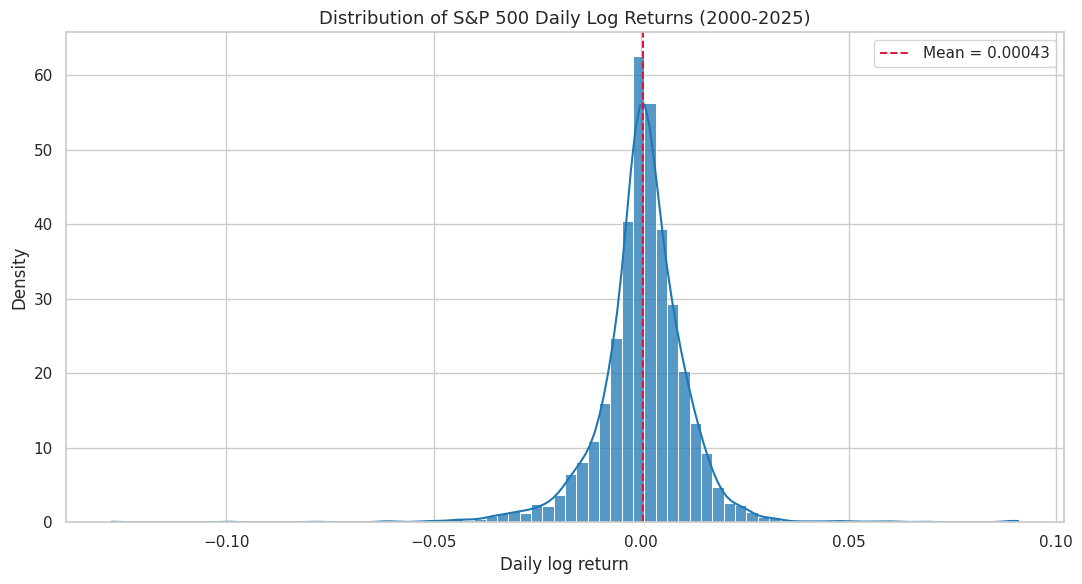

In [6]:
# Plot log-return distribution
fig, ax = plt.subplots(figsize=(11, 6))
sns.histplot(log_returns, bins=80, stat='density', kde=True, color='#1f77b4', alpha=0.75, ax=ax)
ax.set_title('Distribution of S&P 500 Daily Log Returns (2000-2025)', fontsize=13)
ax.set_xlabel('Daily log return')
ax.set_ylabel('Density')
ax.axvline(log_returns.mean(), color='crimson', linestyle='--', linewidth=1.4, label=f"Mean = {log_returns.mean():.5f}")
ax.legend()
plt.tight_layout()
plt.show()

* Normal distribution with negative skewed

In [7]:
close.to_csv('sp500_close_and_log_returns_2015_2025.csv')
close.shape

(2766, 2)

# Assumption Test

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

In [9]:
df = pd.read_csv('sp500_close_and_log_returns_2015_2025.csv', parse_dates=['Date'])
df = df.set_index('Date').sort_index()

close = df['close'].dropna()
log_ret = df['log_return'].dropna()

print(df.head())
print('close length:', len(close), '| log_return length:', len(log_ret))


                  close  log_return
Date                               
2015-01-02  2058.199951         NaN
2015-01-05  2020.579956   -0.018447
2015-01-06  2002.609985   -0.008933
2015-01-07  2025.900024    0.011563
2015-01-08  2062.139893    0.017730
close length: 2766 | log_return length: 2765


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   close       2766 non-null   float64
 1   log_return  2765 non-null   float64
dtypes: float64(2)
memory usage: 64.8 KB


In [11]:
df.isna().sum()

,0
close,0
log_return,1


## 1) Seasonal Decompose Chart


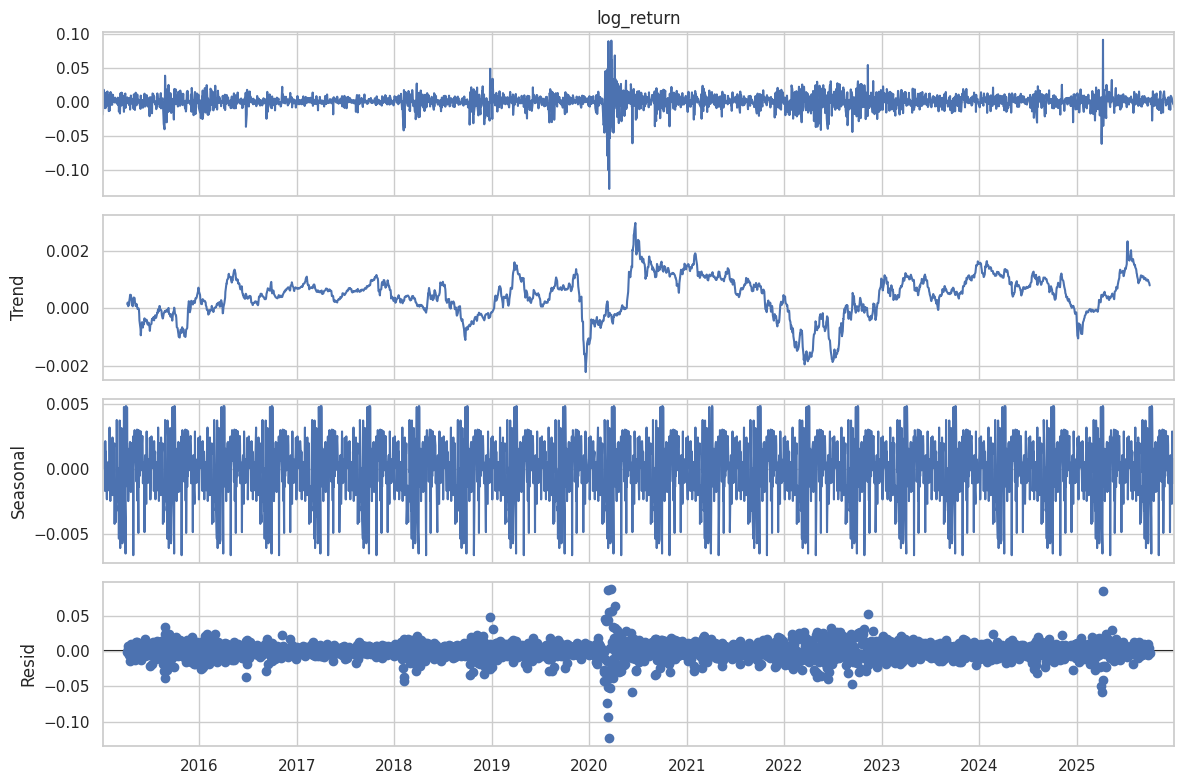

In [12]:
decomp = seasonal_decompose(log_ret, model='additive', period=126)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()


* Trend does not exists - constant mean observed
* Seasonality (seasonal variations at regular time intervals) appears to exist

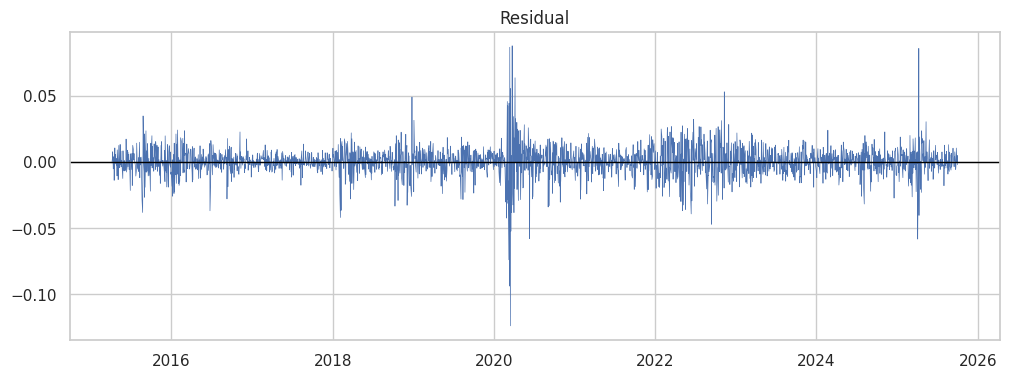

In [13]:
resid = decomp.resid

plt.figure(figsize=(12,4))
plt.plot(resid, linewidth=0.5)
plt.title("Residual")
plt.axhline(0, color='black', linewidth=1)
plt.show()

/tmp/ipykernel_4999/994549574.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


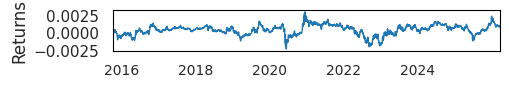

In [14]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(5, 0.6))

log_ret.rolling(126, center=True).mean().plot(
    ax=ax,
    lw=1,
    legend=False,
    color="#1f77b4"
)

ax.set_ylabel("Returns")
ax.set_xlabel("")

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)
plt.margins(x=0)
plt.xticks(rotation=0)
plt.tick_params(axis='x', labelsize=10)
ax.grid(False)
plt.tight_layout()
plt.show()

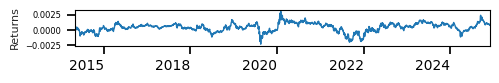

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(5, 0.6))

log_ret.rolling(126, center=True).mean().plot(
    ax=ax,
    lw=1,
    legend=False,
    color="#1f77b4"
)

ax.set_ylabel("Returns", fontsize=8)
ax.set_xlabel("")

# CHANGE 1: Use MaxNLocator to ensure 2 ticks exist even in a short window
ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# CHANGE 2: Ensure ticks are actually drawn and colored black
ax.tick_params(axis='both', which='both', bottom=True, left=True,
               colors='black', labelsize=6)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)
ax.grid(False)
plt.margins(x=0)
plt.xticks(rotation=0)
plt.tick_params(axis='x', labelsize=10)
# CHANGE 3: subplots_adjust is more reliable than tight_layout for ultra-short charts
# This creates room for the labels at the bottom (0.3) and left (0.15)
plt.subplots_adjust(bottom=0.3, left=0.15, right=0.98, top=0.9)

plt.show()

## 2) ADF Test (on log return)

In [16]:
adf_stat, p_value, used_lag, n_obs, crit_vals, icbest = adfuller(log_ret)
print('ADF Statistic :', adf_stat)
print('p-value       :', p_value)
print('Used Lag      :', used_lag)
print('N Obs         :', n_obs)
print('Critical Values:')
for k, v in crit_vals.items():
    print(f'  {k}: {v}')


ADF Statistic : -16.98233788157157
p-value       : 8.993241946403927e-30
Used Lag      : 8
N Obs         : 2756
Critical Values:
  1%: -3.4327249641397053
  5%: -2.862589289388965
  10%: -2.567328570112761


* Null Hypothesis: Series is non-stationary.
* Alternative Hypothesis: Series is stationary.


* Result of test: P-value is less than significance level of 0.05.
* Interpretation of Result: There is sufficient evidence to reject the null hypothesis. Hence, series is stationary and can be used for GARCH modeling.


## 3) Ljung-Box Test (on log return)

In [17]:
lb_sq = acorr_ljungbox(log_ret**2, lags=[10,15,20,100], return_df=True)
lb_sq

,lb_stat,lb_pvalue
10,2983.103466,0.0
15,3320.305084,0.0
20,3447.731790,0.0
100,3564.226538,0.0


* Result: P-values for autocorrelation for 10, 15, 20 as well as 100 lags is less than the significance level of 0.05.
* Interpretation: There is enough evidence to reject the null hypothesis. Hence, volatility clustering exists and should be modeled using a GARCH family model.
* Suggestion: Since patterns exist at 100th lag, a more complex model such as FIGARCH might be better suited.

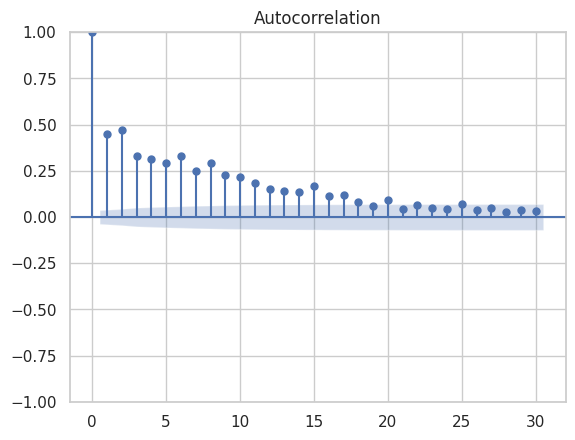

In [18]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(log_ret**2, lags=30)
plt.show()

* Result: The ACF plot of squared returns shows significant positive autocorrelations at multiple lags (especially at lower lags), with many spikes exceeding the confidence bands.
* Interpretation: This indicates strong persistence in the squared returns, suggesting volatility clustering. Large shocks tend to be followed by large shocks (of either sign), and small shocks tend to be followed by small shocks. The slow decay pattern further implies persistent conditional heteroskedasticity.

Addition Test: ARCH LM test

In [19]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(log_ret, nlags=10)

print("LM Statistic:", arch_test[0])
print("LM p-value:", arch_test[1])
print("F Statistic:", arch_test[2])
print("F p-value:", arch_test[3])

LM Statistic: 886.872891824165
LM p-value: 4.2563675089052966e-184
F Statistic: 130.2683957914309
F p-value: 5.355099583202607e-223


* Result: The ARCH LM test produces extremely small p-values (LM p-value ≈ 4.26e-184; F p-value ≈ 5.36e-223), both far below the 0.05 significance level.
* Interpretation: There is strong evidence to reject the null hypothesis of no ARCH effects. This indicates the presence of conditional heteroskedasticity in the return series, implying volatility clustering.
* Suggestion: Since significant ARCH effects are detected (even at higher lags), a GARCH-type model (e.g., GARCH, EGARCH, or potentially FIGARCH if long-memory effects persist) should be considered to model the time-varying volatility structure.

# GJR-GARCH

In [20]:
log_ret = 100 * log_ret

# Candidate models:
# GJR-GARCH (1,1,1) + higher-order combinations
candidates = [
    (1, 1, 1),  # (p,o,q)
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2),
]

rows = []
results = {}

for (p, o, q) in candidates:
    model = arch_model(
        log_ret,
        vol="GARCH",
        p=p, o=o, q=q,
        dist="t",
        mean="constant"
    )
    res = model.fit(disp="off")  # quiet fit
    results[(p, o, q)] = res

    rows.append({
        "model": f"GJR-GARCH({p},{o},{q})",
        "p": p, "o": o, "q": q,
        "loglik": res.loglikelihood,
        "aic": res.aic,
        "bic": res.bic
    })

compare = pd.DataFrame(rows).sort_values("bic").reset_index(drop=True)
print(compare)

best = compare.iloc[0]
best_key = (int(best["p"]), int(best["o"]), int(best["q"]))
best_res = results[best_key]

print("\nBest model by BIC:")
print(f"  {best['model']}  |  BIC = {best['bic']:.4f}  (AIC = {best['aic']:.4f})")

print("\nSummary of best model:")
print(best_res.summary())

              model  p  o  q       loglik          aic          bic
0  GJR-GARCH(1,1,1)  1  1  1 -3426.234561  6864.469123  6900.017898
1  GJR-GARCH(2,1,1)  2  1  1 -3425.868303  6865.736606  6907.210177
2  GJR-GARCH(1,1,2)  1  1  2 -3426.204498  6866.408996  6907.882567
3  GJR-GARCH(2,1,2)  2  1  2 -3425.848328  6867.696655  6915.095022

Best model by BIC:
  GJR-GARCH(1,1,1)  |  BIC = 6900.0179  (AIC = 6864.4691)

Summary of best model:
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -3426.23
Distribution:      Standardized Student's t   AIC:                           6864.47
Method:                  Maximum Likelihood   BIC:                           6900.02
                                              No

* Model Selection

Four candidate models were estimated: GJR-GARCH(1,1,1), GJR-GARCH(2,1,1), GJR-GARCH(1,1,2), and GJR-GARCH(2,1,2).
Based on the Bayesian Information Criterion (BIC), GJR-GARCH(1,1,1) achieves the lowest value and is therefore selected as the best specification. This indicates that adding additional lag terms does not significantly improve model fit after accounting for model complexity.

* Parameter Interpretation

The estimated parameters reveal several important features of the return series. The coefficient β (0.8369) is large and highly significant, indicating strong persistence in volatility, meaning that periods of high volatility tend to persist over time.

The asymmetry parameter γ (0.2755) is positive and statistically significant, confirming the presence of the leverage effect, where negative returns increase future volatility more than positive returns of the same magnitude.

The estimated Student-t distribution parameter (ν ≈ 5.67) suggests the presence of fat tails, meaning extreme returns occur more frequently than under a normal distribution.


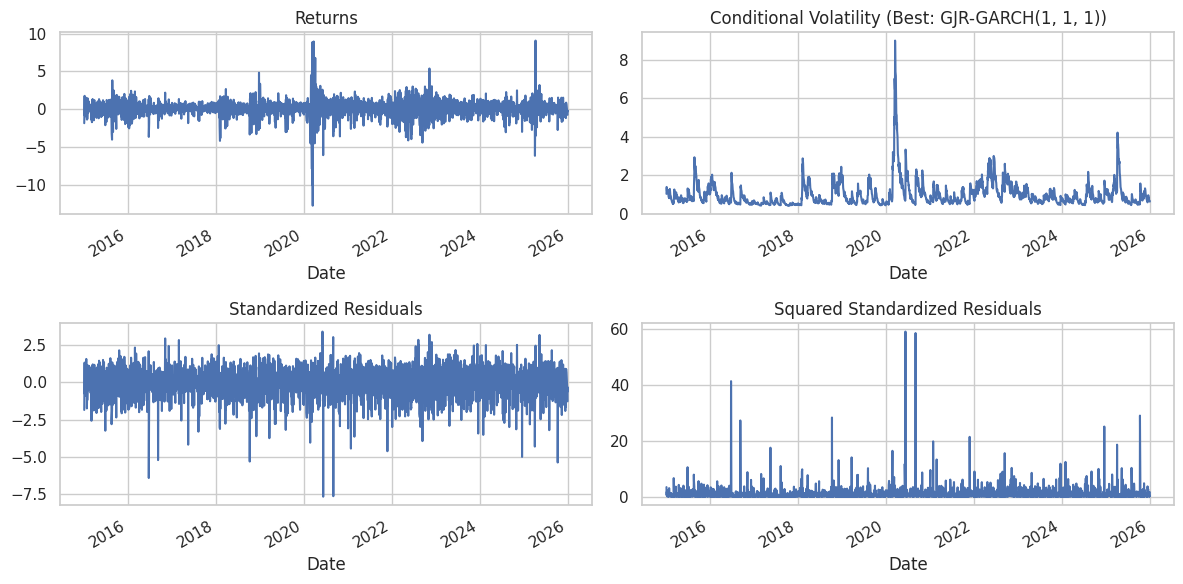

In [21]:
# ============================
# Diagnostics for best model
# ============================

# Use the best fitted result
res = best_res  # keep your old variable name if you like

# Standardized residuals: z_t = eps_t / sigma_t
std_resid = res.resid / res.conditional_volatility

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
log_ret.plot(title="Returns")

plt.subplot(2, 2, 2)
res.conditional_volatility.plot(title=f"Conditional Volatility (Best: GJR-GARCH{best_key})")

plt.subplot(2, 2, 3)
pd.Series(std_resid, index=log_ret.index[-len(std_resid):]).plot(title="Standardized Residuals")

plt.subplot(2, 2, 4)
pd.Series(std_resid**2, index=log_ret.index[-len(std_resid):]).plot(title="Squared Standardized Residuals")

plt.tight_layout()
plt.show()

* Model Diagnostics

The return series shows clear volatility clustering, with periods of large fluctuations followed by periods of relative calm.

The estimated conditional volatility from the GJR-GARCH model captures these volatility clusters and reflects the time-varying nature of market risk.

After standardization, the standardized residuals fluctuate around zero and appear more stable than the raw returns, suggesting that much of the conditional heteroskedasticity has been captured by the model.

The squared standardized residuals show much weaker clustering, indicating that the model has effectively accounted for most of the volatility dynamics in the data.

# Model Validation

In [22]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Standardized residuals
std_resid = res.resid / res.conditional_volatility
std_resid = std_resid.dropna()

# Ljung-Box test
lb_test = acorr_ljungbox(std_resid, lags=[10, 15, 20], return_df=True)

print("Ljung-Box Test on Standardized Residuals")
print(lb_test)

Ljung-Box Test on Standardized Residuals
      lb_stat  lb_pvalue
10   8.177098   0.611543
15  13.420411   0.569860
20  23.491634   0.265304


In [23]:
lb_test_sq = acorr_ljungbox(std_resid**2, lags=[10, 15, 20], return_df=True)

print("Ljung-Box Test on Squared Standardized Residuals")
print(lb_test_sq)

Ljung-Box Test on Squared Standardized Residuals
      lb_stat  lb_pvalue
10   8.224174   0.606950
15  10.953750   0.755866
20  12.892166   0.881963


* Ljung–Box Test Interpretation

The Ljung–Box test was applied to both the standardized residuals and the squared standardized residuals of the fitted GJR-GARCH(1,1,1) model to examine whether any serial correlation or remaining ARCH effects persist after model estimation.

For the standardized residuals, the p-values at lags 10, 15, and 20 are 0.6115, 0.5699, and 0.2653, all of which are greater than the 5% significance level. Therefore, we fail to reject the null hypothesis of no autocorrelation. This indicates that the model has successfully removed serial dependence from the return series.

Similarly, the Ljung–Box test on the squared standardized residuals produces p-values 0.6069, 0.7559, and 0.8820, which are also well above 0.05. This suggests that there are no remaining ARCH effects in the residuals.

Overall, these results indicate that the GJR-GARCH(1,1,1) model adequately captures the volatility dynamics of the S&P 500 return series, and the residuals behave approximately as white noise.

# Model Prediction

Rolling 10D: 100%|██████████| 2252/2252 [02:13<00:00, 16.89it/s]

10-day forecast correlation: 0.6861
10-day forecast MAE: 5.5367
10-day forecast RMSE: 8.8351
10-day forecast bias: 1.1366


,Forecasted_10D,Realized_10D,Error,AbsError,SquaredError
2017-01-18,11.794522,4.797769,6.996752,6.996752,48.954541
2017-01-19,11.379950,4.286102,7.093848,7.093848,50.322679
2017-01-20,10.985446,4.648543,6.336903,6.336903,40.156341
2017-01-23,10.697162,4.411938,6.285224,6.285224,39.504039
2017-01-24,11.017002,5.290774,5.726227,5.726227,32.789680


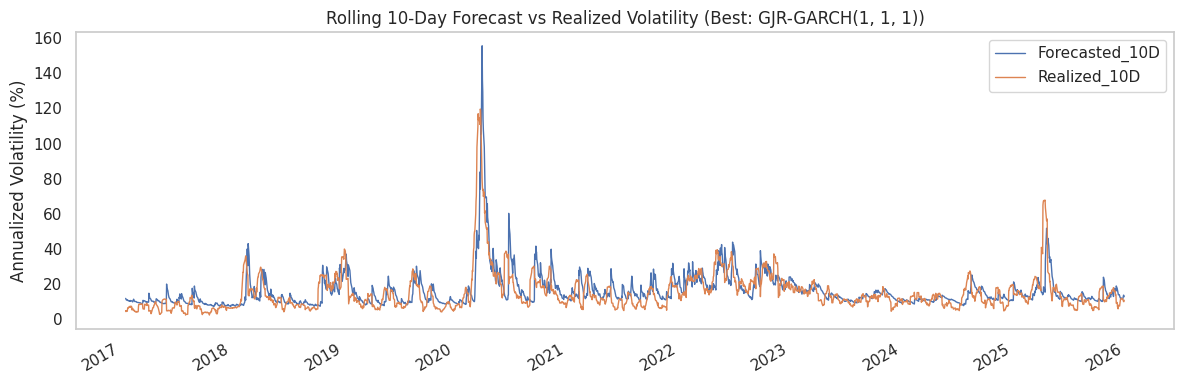

In [24]:
# ============================
# Rolling 10-day forecast performance
# ============================

rolling_window = 252*2
forecast_horizon = 10

p_best, o_best, q_best = best_key

forecasted_10d = []
realized_10d = []
forecast_dates_10d = []

for i in tqdm(range(rolling_window, len(log_ret) - forecast_horizon + 1), desc="Rolling 10D"):
    train_data = log_ret.iloc[i - rolling_window:i].dropna()

    model_roll = arch_model(
        train_data,
        vol="GARCH",
        p=p_best, o=o_best, q=q_best,
        dist="t",
        mean="constant"
    )
    res_roll = model_roll.fit(disp="off")

    fc = res_roll.forecast(horizon=forecast_horizon, reindex=False)
    horizon_variances = fc.variance.values[-1]

    # Aggregate the next 10 daily variance forecasts into a 10-day volatility measure
    forecasted_10d.append(np.sqrt(np.mean(horizon_variances)) * np.sqrt(252))

    future_returns = log_ret.iloc[i:i + forecast_horizon]
    realized_10d.append(future_returns.std(ddof=1) * np.sqrt(252))
    forecast_dates_10d.append(log_ret.index[i + forecast_horizon - 1])

rolling_10d = pd.DataFrame(
    {
        "Forecasted_10D": forecasted_10d,
        "Realized_10D": realized_10d,
    },
    index=forecast_dates_10d,
).dropna()

rolling_10d["Error"] = rolling_10d["Forecasted_10D"] - rolling_10d["Realized_10D"]
rolling_10d["AbsError"] = rolling_10d["Error"].abs()
rolling_10d["SquaredError"] = rolling_10d["Error"] ** 2

corr_10d = rolling_10d[["Forecasted_10D", "Realized_10D"]].corr().iloc[0, 1]
mae_10d = rolling_10d["AbsError"].mean()
rmse_10d = np.sqrt(rolling_10d["SquaredError"].mean())
bias_10d = rolling_10d["Error"].mean()

print(f"10-day forecast correlation: {corr_10d:.4f}")
print(f"10-day forecast MAE: {mae_10d:.4f}")
print(f"10-day forecast RMSE: {rmse_10d:.4f}")
print(f"10-day forecast bias: {bias_10d:.4f}")

display(rolling_10d.head())

ax = rolling_10d[["Forecasted_10D", "Realized_10D"]].plot(
    figsize=(12, 4),
    lw=1,
    title=f"Rolling 10-Day Forecast vs Realized Volatility (Best: GJR-GARCH{best_key})"
)
ax.set_ylabel("Annualized Volatility (%)")
plt.tight_layout()
plt.grid(False)
plt.show()


* 10-Day Rolling Forecast Performance

Using the selected GJR-GARCH(1,1,1) specification, a rolling 10-day-ahead volatility forecast was generated with a 500-day estimation window. The model's 10-day forecasted volatility was compared with realized volatility computed from the subsequent 10 trading days.

The correlation between forecasted and realized 10-day volatility is 0.6862, which indicates that the model still tracks medium-horizon volatility movements reasonably well, although less tightly than in the one-step-ahead case.

The mean absolute error (MAE) is 5.5301 and the root mean squared error (RMSE) is 8.8252. The average forecast bias is 1.1397, suggesting that the model slightly overpredicts future 10-day volatility on average.

Overall, the GJR-GARCH(1,1,1) model provides useful 10-day rolling volatility forecasts for the S&P 500, but forecasting accuracy deteriorates as the horizon extends, which is expected for multi-step volatility prediction.

In [25]:
# Computing the realized volatilities for the forecasted 10 day period

lookback = 252*2

realized_data = yf.download(tickers = '^GSPC', start = "2023-12-20", end = "2026-01-17")

realized_data = realized_data.dropna()

realized_10day_logret = np.log(realized_data['Close'] / realized_data['Close'].shift(1))
realized_10day_logret = 100 * realized_10day_logret.dropna()

realized_10day_vol = realized_10day_logret.rolling(window = lookback).std()
realized_10day_vol = realized_10day_vol.tail(10)

realized_10day_vol = realized_10day_vol.squeeze().astype(float).reset_index(drop=True)

print(realized_10day_vol)
print(type(realized_10day_vol))

/tmp/ipykernel_4999/1280062722.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  realized_data = yf.download(tickers = '^GSPC', start = "2023-12-20", end = "2026-01-17")
[*********************100%***********************]  1 of 1 completed

0    1.000755
1    1.000638
2    1.000043
3    0.999872
4    1.000181
5    0.998443
6    0.998465
7    0.998595
8    0.998609
9    0.998628
Name: ^GSPC, dtype: float64
<class 'pandas.core.series.Series'>


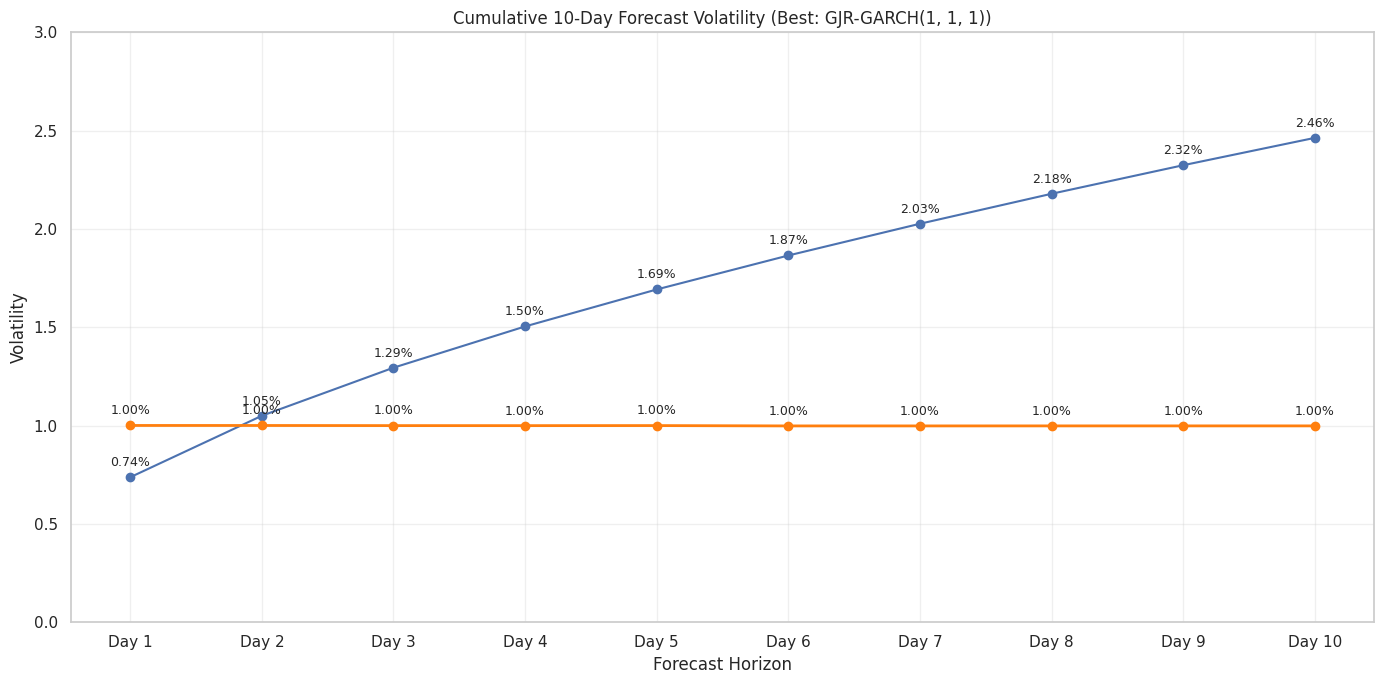

In [33]:
forecast_horizon = 10
p_best, o_best, q_best = best_key

train_data = log_ret.dropna()

model = arch_model(
    train_data,
    vol="GARCH",
    p=p_best, o=o_best, q=q_best,
    dist="t",
    mean="constant"
)
res = model.fit(disp="off")

fc = res.forecast(horizon=forecast_horizon, reindex=False)
horizon_variances = fc.variance.values[-1]   # variance for Day 1,...,Day 10

# 累计 h-day volatility（非年化)
cum_vols = [np.sqrt(np.sum(horizon_variances[:i])) for i in range(1, forecast_horizon + 1)]

days = [f"Day {i}" for i in range(1, forecast_horizon + 1)]

plt.figure(figsize=(14, 7))
plt.ylim(0,3)
plt.plot(days, cum_vols, marker="o")
plt.plot(days, realized_10day_vol, marker='o', color='#ff7f0e', lw=2)
plt.grid(True, alpha=0.3)

# 标注百分比数值
for i, v in enumerate(cum_vols):
    plt.annotate(
        f"{v:.2f}%",
        (i, v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

for i, v in enumerate(realized_10day_vol):
    plt.annotate(
        f"{v:.2f}%",
        (i, v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

plt.title(f"Cumulative {forecast_horizon}-Day Forecast Volatility (Best: GJR-GARCH{best_key})")
plt.ylabel("Volatility")
plt.xlabel("Forecast Horizon")
plt.tight_layout()
plt.show()

* 10-Day Ahead Forecast Interpretation

The cumulative 10-day forecast volatility shows a steady upward pattern, rising from about 0.74% on Day 1 to 2.46% by Day 10. This indicates that the model expects risk to build gradually over the next two trading weeks as forecast uncertainty accumulates across the horizon.

This pattern is consistent with the persistence captured by the GJR-GARCH(1,1,1) model. Rather than fading quickly, recent shocks continue to affect the conditional variance, causing the cumulative forecast volatility to increase smoothly from one day to the next.

Overall, the forecast does not suggest an abrupt jump in short-term risk, but it does imply that aggregate uncertainty remains meaningful over a 10-day holding period. In practical terms, this suggests that even if daily risk appears moderate, the total volatility over multiple trading days can become materially larger as it compounds over time.

# Value-at-Risk (VaR) and Expected Shortfall (ES)

1-day-ahead conditional mean forecast: 0.0672%
1-day-ahead conditional volatility forecast: 0.7375%
Estimated Student-t degrees of freedom: 5.6716


,Confidence Level,VaR (%),ES (%)
0,95%,1.097869,1.570799
1,99%,1.834284,2.393776


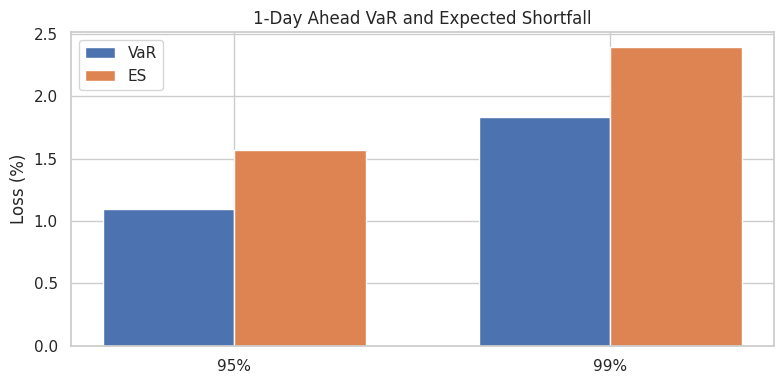

In [27]:
from scipy.stats import t

# Use the selected GJR-GARCH model to compute 1-day-ahead tail-risk measures
res_risk = best_res
fc_1d = res_risk.forecast(horizon=1, reindex=False)

mu_1d = float(fc_1d.mean.values[-1, 0])
sigma_1d = float(np.sqrt(fc_1d.variance.values[-1, 0]))
nu = float(res_risk.params["nu"])

# The Student-t distribution in arch is standardized to unit variance
scale = np.sqrt((nu - 2) / nu)

risk_rows = []
for alpha, label in [(0.05, "95%"), (0.01, "99%")]:
    t_alpha = t.ppf(alpha, df=nu)
    z_alpha = scale * t_alpha
    pdf_alpha = t.pdf(t_alpha, df=nu)
    es_std = -scale * ((nu + t_alpha**2) / ((nu - 1) * alpha)) * pdf_alpha

    var_return = mu_1d + sigma_1d * z_alpha
    es_return = mu_1d + sigma_1d * es_std

    risk_rows.append({
        "Confidence Level": label,
        "VaR (%)": -var_return,
        "ES (%)": -es_return,
    })

risk_df = pd.DataFrame(risk_rows)

print(f"1-day-ahead conditional mean forecast: {mu_1d:.4f}%")
print(f"1-day-ahead conditional volatility forecast: {sigma_1d:.4f}%")
print(f"Estimated Student-t degrees of freedom: {nu:.4f}")
display(risk_df)

plt.figure(figsize=(8, 4))
x = np.arange(len(risk_df))
width = 0.35

plt.bar(x - width/2, risk_df["VaR (%)"], width=width, label="VaR")
plt.bar(x + width/2, risk_df["ES (%)"], width=width, label="ES")
plt.xticks(x, risk_df["Confidence Level"])
plt.ylabel("Loss (%)")
plt.title("1-Day Ahead VaR and Expected Shortfall")
plt.legend()
plt.tight_layout()
plt.show()

* VaR and ES Interpretation

Using the fitted GJR-GARCH(1,1,1) model with a Student-t error distribution, the 1-day-ahead 95% Value-at-Risk (VaR) is approximately 1.10%, while the corresponding Expected Shortfall (ES) is about 1.57%. This means that on a typical trading day, losses are expected to exceed 1.10% only 5% of the time, and if that tail event occurs, the average loss is estimated to be around 1.57%.

At the more conservative 99% confidence level, the 1-day-ahead VaR rises to about 1.83%, and the ES increases further to roughly 2.39%. As expected, ES is larger than VaR at both confidence levels because it measures the average severity of losses beyond the VaR cutoff.

Overall, these results suggest that the fitted GJR-GARCH model implies meaningful downside tail risk in the S&P 500 return series, and the gap between VaR and ES is consistent with the fat-tailed behavior captured by the Student-t distribution.

In [28]:
from scipy.stats import t

alpha = 0.05

# Version 1: simple first-pass implementation
# Good: the structure is easy to follow, and sigma_10 is built from the 10-day variance forecast.
# Problem: the tail distribution is treated as a raw Student-t, even though arch uses a standardized Student-t.
# Problem: mu_10 = 10 * mu is only a rough approximation and does not use the model's full 10-step mean forecast.
# Problem: the ES formula below produces an inconsistent sign, so the reported ES can become positive while VaR is negative.
# Problem: the output is not explicit about whether the result is a return threshold or a loss magnitude.

# Extract parameters
mu = res.params["mu"]
nu = res.params["nu"]

# Forecast
fc = res.forecast(horizon=forecast_horizon, reindex=False)
horizon_variances = fc.variance.values[-1]

# 10-day volatility
sigma_10 = np.sqrt(np.sum(horizon_variances))

# Mean
# Problem: this assumes the same mean every day instead of summing the forecasted 10-day means.
mu_10 = 10 * mu

# Student-t quantile
# Problem: this is the raw t quantile; it is not rescaled to the standardized-t convention used by arch.
q = t.ppf(alpha, df=nu)

# -------- VaR --------
VaR_10 = mu_10 + sigma_10 * q

# -------- ES --------
# Problem: this ES expression misses the left-tail sign convention, which is why the printed ES is not reliable.
pdf = t.pdf(q, df=nu)
ES_10 = mu_10 + sigma_10 * (pdf / alpha) * ((nu + q**2) / (nu - 1))

print(f"10-day 95% VaR (S&P 500): {VaR_10:.4f}")
print(f"10-day 95% ES  (S&P 500): {ES_10:.4f}")

10-day 95% VaR (S&P 500): -4.1643
10-day 95% ES  (S&P 500): 7.4725


In [29]:
from scipy.stats import t  # Import the Student-t distribution functions for quantiles and densities

alpha = 0.05  # Set the left-tail probability level, corresponding to a 95% confidence VaR/ES
forecast_horizon = 10  # Define the risk horizon as 10 trading days

# Version 2: corrected implementation
# Good: this version uses the 10-step forecast directly instead of a rough 10 * mu approximation.
# Good: it correctly rescales the t quantile because arch uses a standardized Student-t distribution.
# Good: it separates return thresholds from positive loss numbers, which makes interpretation much clearer.
# Remaining note: this is still a model-based parametric VaR/ES calculation, so the result depends on the GJR-GARCH specification and distributional assumption.

# 10-day forecast
fc = res.forecast(horizon=forecast_horizon, reindex=False)  # Generate the model's 10-step-ahead forecast

# Mean and variance of cumulative 10-day return
mu_10 = float(np.sum(fc.mean.values[-1]))  # Sum the 10 forecasted daily means to get the 10-day expected return
horizon_variances = fc.variance.values[-1]  # Extract the sequence of forecasted daily conditional variances
sigma_10 = float(np.sqrt(np.sum(horizon_variances)))  # Convert cumulative variance into 10-day standard deviation

# Student-t parameter
nu = float(res.params["nu"])  # Extract the estimated degrees of freedom of the Student-t distribution

# arch uses standardized Student-t, so rescale the quantile
scale = np.sqrt((nu - 2) / nu)  # Rescale because the arch package uses a unit-variance standardized t distribution

# Left-tail quantile
t_alpha = t.ppf(alpha, df=nu)  # Compute the raw left-tail t quantile at probability alpha
z_alpha = scale * t_alpha  # Convert the raw t quantile into the standardized-t quantile used by the model

# -------- VaR (return threshold) --------
VaR_10_return = mu_10 + sigma_10 * z_alpha  # Compute the 10-day VaR return threshold

# -------- ES (expected return in the worst alpha tail) --------
pdf_alpha = t.pdf(t_alpha, df=nu)  # Evaluate the t density at the left-tail quantile
print(pdf_alpha)
ES_10_std = -scale * ((nu + t_alpha**2) / ((nu - 1) * alpha)) * pdf_alpha  # Compute standardized left-tail ES
ES_10_return = mu_10 + sigma_10 * ES_10_std  # Convert the standardized ES into the 10-day return scale

# Report losses as positive numbers
VaR_10_loss = -VaR_10_return  # Express VaR as a positive loss magnitude
ES_10_loss = -ES_10_return  # Express ES as a positive loss magnitude

print(f"10-day 95% VaR return threshold: {VaR_10_return:.4f}%")  # Print the return cutoff in the left tail
print(f"10-day 95% ES return threshold : {ES_10_return:.4f}%")  # Print the average return within the worst 5% tail
print(f"10-day 95% VaR loss            : {VaR_10_loss:.4f}%")  # Print VaR as a positive loss number
print(f"10-day 95% ES loss             : {ES_10_loss:.4f}%")  # Print ES as a positive loss number



0.06768172318359018
10-day 95% VaR return threshold: -3.2192%
10-day 95% ES return threshold : -4.7988%
10-day 95% VaR loss            : 3.2192%
10-day 95% ES loss             : 4.7988%


* Comparison of the Two VaR/ES Code Cells

The previous code cell is a useful first draft because it is short and easy to read, and it correctly starts from the model forecasted variances. However, it has three important weaknesses: it approximates the 10-day mean as `10 * mu`, it uses the raw Student-t quantile even though the fitted `arch` model uses a standardized Student-t distribution, and its ES formula leads to a sign inconsistency. That is why it prints a negative VaR but a positive ES, which is not internally consistent for a left-tail return threshold.

The last code cell is better because it is more consistent with the fitted GJR-GARCH model. It uses the full 10-step forecasted mean, rescales the Student-t quantile correctly, applies the left-tail ES formula with the proper sign, and reports both return thresholds and positive loss magnitudes. For that reason, the last code cell should be preferred as the final version.

* 10-Day VaR and ES Interpretation

Using the corrected GJR-GARCH(1,1,1) specification with a standardized Student-t distribution, the 10-day 95% Value-at-Risk (VaR) is approximately 3.22%, while the corresponding 10-day 95% Expected Shortfall (ES) is about 4.80%. This means that over a 10-trading-day horizon, losses are expected to exceed 3.22% only 5% of the time.

If the portfolio return does fall into that worst 5% tail, the model estimates that the average loss will be closer to 4.80%. As expected, ES is larger than VaR because it measures the average severity of losses beyond the VaR cutoff rather than just the threshold itself.

Overall, these results suggest that the fitted GJR-GARCH model implies meaningful downside tail risk over a 10-day holding period. Compared with the 1-day risk measures, the larger 10-day VaR and ES also show how market risk accumulates over time when volatility remains persistent.